# Used Car Price — first look at the data

Dataset is OLX Pakistan's used-car listings — brand, model, condition, fuel,
kilometers driven, price, registered city, and how the seller wants to be
paid (cash vs. installment/leasing). Just under 25,000 rows.

I wanted to look at this before writing `src/data_processing.py` — this
dataset turned out to be messier than I expected, so most of this notebook
is figuring out what to do about that rather than pretty charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# latin-1, not utf-8 — a few city names (Sheikhūpura and similar) break
# the default encoding.
df = pd.read_csv("../data/olx_used_cars_pakistan.csv", encoding="latin1")
df.shape

(24973, 9)

In [2]:
df.head()

,Brand,Condition,Fuel,KMs Driven,Model,Price,Registered City,Transaction Type,Year
0,Toyota,Used,Diesel,1.0,Prado,2100000,Karachi,Cash,1997.0
1,Suzuki,Used,Petrol,100000.0,Bolan,380000,Karachi,Cash,2006.0
2,Suzuki,Used,CNG,12345.0,Bolan,340000,Karachi,Cash,1998.0
3,Suzuki,Used,Petrol,94000.0,Alto,535000,Karachi,Cash,2010.0
4,Toyota,Used,Petrol,100000.0,Corolla XLI,1430000,Karachi,Cash,2013.0


## Missing values and duplicates

This one has real gaps, not just a couple of stray nulls.

In [3]:
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())

Brand               2137
Condition           2136
Fuel                2445
KMs Driven          2286
Model               2448
Price                  0
Registered City     4636
Transaction Type    2445
Year                2284
dtype: int64

duplicate rows: 3774


Registered City is missing for about 4,600 listings (18%) — sellers
just skip that field sometimes. Brand/Fuel/Model/Year are missing together
in a smaller, overlapping set of rows, which looks like incomplete ad
scrapes rather than a pattern in the data itself. Price has no nulls,
which makes sense — a listing with no price wouldn't be a listing.

Decision: drop rows missing the columns that actually matter for
prediction (brand, condition, fuel, mileage, price, transaction type,
year). For city, missing isn't the same kind of problem — a car's price
doesn't depend on whether the seller filled in a city field — so instead
of dropping those rows I keep them and label the city "Not Specified".

In [4]:
df["Condition"].value_counts(dropna=False)

Condition
Used    18472
New      4365
NaN      2136
Name: count, dtype: int64

New vs. used listings are mixed together. A "new" listing on OLX is
someone reselling a never-registered/showroom car, and its price follows
completely different rules than depreciation — so for a *used* car
estimator, new listings are out of scope, not just noise. Filtering to
`Condition == "Used"` drops about 4,000 rows but keeps the target variable
meaning one consistent thing.

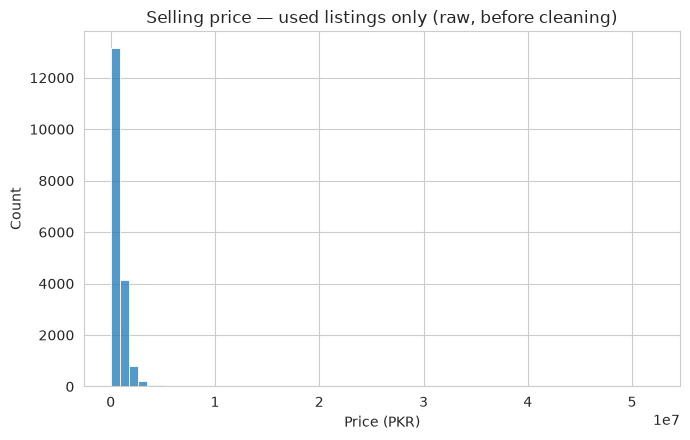

In [5]:
used = df[df["Condition"] == "Used"]
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(used["Price"].dropna(), bins=60, ax=ax)
ax.set_title("Selling price — used listings only (raw, before cleaning)")
ax.set_xlabel("Price (PKR)")
plt.tight_layout()
plt.savefig("../reports/figures/raw_price_distribution.png", dpi=110)
plt.show()

Long right tail, same shape as the raw mileage and year columns below
— a handful of listings sit way outside anything plausible (one car priced
above 8 crore PKR, one with a "1915" model year, mileages past a million
km). Rather than pick manual cutoffs for each column, the cleaning script
uses a widened IQR rule (3x IQR) on price, mileage, and car age — wide
enough that genuinely expensive cars and near-new low-mileage listings
survive, but the clear data-entry errors get trimmed.

In [6]:
used["Year"].describe()

count    18335.000000
mean      2004.480665
std          9.460911
min       1915.000000
25%       2000.000000
50%       2007.000000
75%       2012.000000
max       2019.000000
Name: Year, dtype: float64

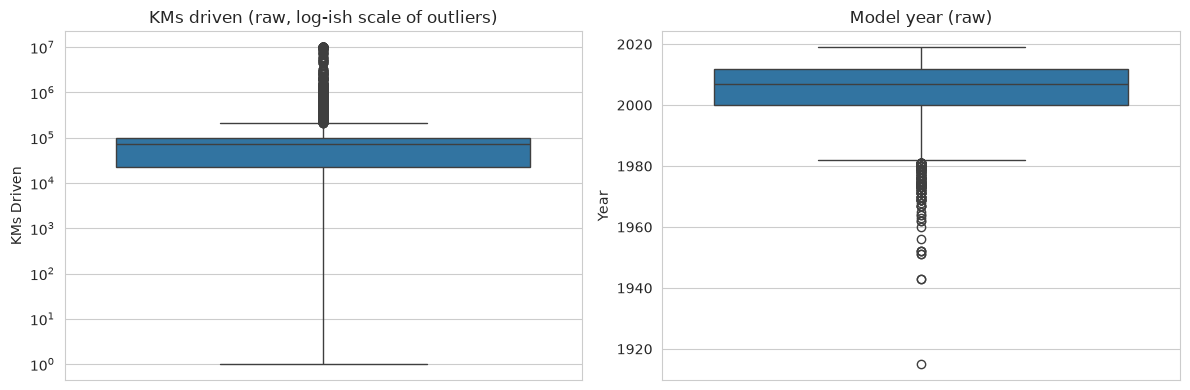

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=used["KMs Driven"].dropna(), ax=axes[0])
axes[0].set_title("KMs driven (raw, log-ish scale of outliers)")
axes[0].set_yscale("log")
sns.boxplot(y=used["Year"].dropna(), ax=axes[1])
axes[1].set_title("Model year (raw)")
plt.tight_layout()
plt.savefig("../reports/figures/raw_outliers.png", dpi=110)
plt.show()

Confirms it — mileage has a cluster of values past 1,000,000 km
(not a real number of kilometers for a car still being resold), and
model year dips down toward 1915, decades before OLX or the used-car
market this data represents existed. Both get handled by the same IQR
trim as price.

most recent listing year in the data: 2019


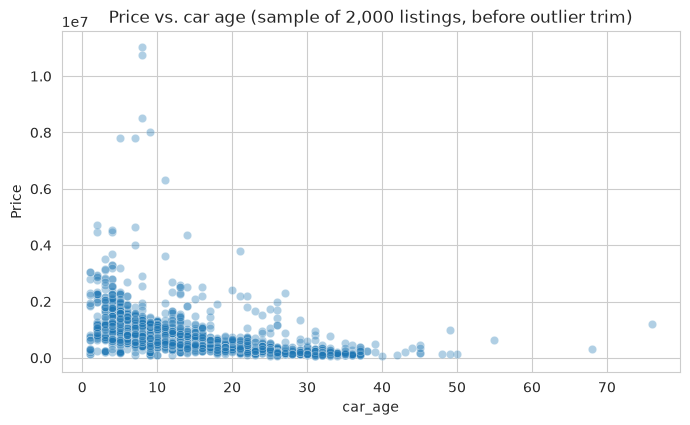

In [8]:
REFERENCE_YEAR = int(used["Year"].max())
print("most recent listing year in the data:", REFERENCE_YEAR)
cleaned_preview = used.copy()
cleaned_preview["car_age"] = REFERENCE_YEAR - cleaned_preview["Year"]

fig, ax = plt.subplots(figsize=(7, 4.5))
sample = cleaned_preview.dropna(subset=["car_age", "Price"]).sample(2000, random_state=42)
sns.scatterplot(data=sample, x="car_age", y="Price", alpha=0.35, ax=ax)
ax.set_title("Price vs. car age (sample of 2,000 listings, before outlier trim)")
plt.tight_layout()
plt.savefig("../reports/figures/price_vs_age.png", dpi=110)
plt.show()

Same depreciation curve shape I'd expect — steep drop in the first
decade, flattens out after. `car_age` computed relative to 2019 (the most
recent listing year in the data), not today's date, for the same reason
as before: the model is calibrated to when the data was collected.

In [9]:
top_brands = used["Brand"].value_counts().head(12)
top_brands

Brand
Suzuki          8313
Toyota          3749
Honda           2663
Daihatsu        1903
Nissan           527
Mitsubishi       378
Hyundai          247
Other Brands     154
KIA              125
Mercedes          79
Mazda             76
Daewoo            67
Name: count, dtype: int64

Suzuki alone is nearly half the used listings, which tracks — Suzuki's
been the dominant brand in Pakistan's car market for decades because of
how long the Mehran/Cultus/Alto stayed the default first car here. Toyota,
Honda, and Daihatsu make up most of the rest. "Range Rover" shows up as
its own brand entry, which is really a Land Rover model line rather than a
separate manufacturer — fixed in `src/data_processing.py` by merging it
into "Land Rover", the same kind of fix as the CarDekho brand cleanup
pattern.

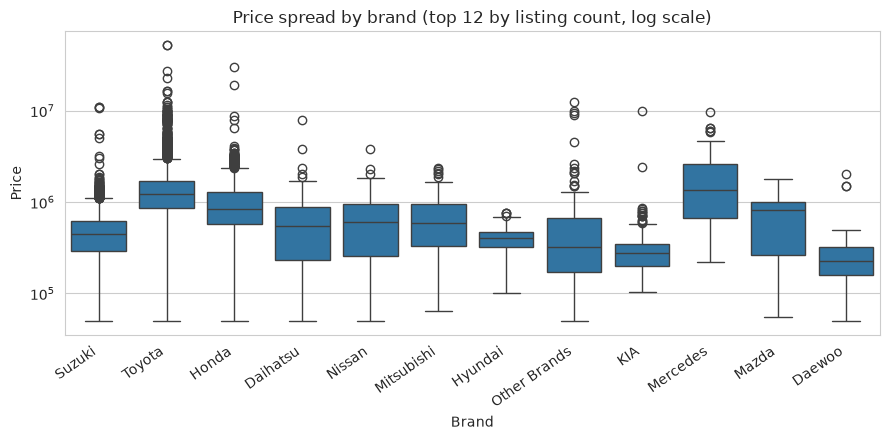

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = used[used["Brand"].isin(top_brands.index)]
sns.boxplot(data=plot_df, x="Brand", y="Price", ax=ax, order=top_brands.index)
ax.set_yscale("log")
ax.set_title("Price spread by brand (top 12 by listing count, log scale)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/price_by_brand.png", dpi=110)
plt.show()

Big spread — Daewoo and Suzuki cluster low, Toyota noticeably higher,
and the low-volume luxury brands (BMW, Mercedes, Audi) sit well above
everything else despite having only a handful of listings each. Brand is
clearly carrying real price signal, worth keeping as a feature even though
it means one-hot encoding a fairly long tail of manufacturers.

In [11]:
used["Registered City"].value_counts(dropna=False).head(15)

Registered City
Karachi          13853
Lahore            1620
NaN               1542
Islamabad          794
Rawalpindi         139
Multan              91
Faisalabad          85
Peshawar            61
Bahawalpur          35
Sialkot             30
Hyderabad           20
Gujranwala          18
Quetta              14
Rahimyar Khan       12
Sargodha            12
Name: count, dtype: int64

Karachi alone accounts for roughly three-quarters of all listings —
OLX's used-car activity is heavily concentrated there, with Lahore and
Islamabad a distant second and third. Everything past the top dozen or so
cities has so few listings that one-hot encoding them individually would
mostly just add sparse noise, so the cleaning script buckets anything
below 10 listings into "Other City".

In [12]:
used["Transaction Type"].value_counts(dropna=False)

Transaction Type
Cash                   17624
Installment/Leasing      574
NaN                      274
Name: count, dtype: int64

Most sales are cash, but a meaningful minority go through
installment/leasing — worth keeping as a feature since financed purchases
often carry different pricing than straight cash deals (dealers pricing in
markup, or leasing companies setting terms). Not something the CarDekho
version of this project had a column for at all.

### Takeaways for `src/data_processing.py`

- Drop rows missing brand, condition, fuel, mileage, price, transaction
  type, or year — these can't be usefully imputed for a specific listing.
- Fill missing city with "Not Specified" rather than dropping — a car's
  price doesn't depend on whether that field got filled in.
- Keep only `Condition == "Used"` — new-car listings follow different
  pricing rules entirely.
- Merge "Range Rover" into "Land Rover", fold the site's own "Other
  Brands" bucket into "Other".
- Convert `Year` into `car_age` relative to 2019 (latest listing year).
- Trim outliers on price, mileage, and car age with a widened (3x) IQR
  rule.
- Bucket brands under 5 listings and cities under 10 listings into
  "Other" / "Other City".

That's what actually ships in the cleaning module — this notebook is where
I worked out why.